In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Garantir reprodutibilidade dos experimentos
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

### configurações

In [ ]:
CONFIG = {
    "img_size": 224,
    "batch_size": 16, # Ideal para os 4GB de VRAM da GTX 1650
    "epochs": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4, # Regularização L2
    "patience": 3, # Early stopping
    "data_dir": r" " #substitua pelo seu path absoluto. Ex: r"C:\Users\Seu\Caminho\archive\chest_xray"
}

##### Configuração de hardware

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Instância rodando em: {device}")
if torch.cuda.is_available():
    print(f"GPU Detectada: {torch.cuda.get_device_name(0)}")

Instância rodando em: cuda
GPU Detectada: NVIDIA GeForce GTX 1650


### EDA

--------------------------------------------------
DISTRIBUIÇÃO DAS CLASSES NO CONJUNTO DE TREINO
--------------------------------------------------
Classe 'NORMAL': 1108 imagens (27.03%)
Classe 'PNEUMONIA': 2991 imagens (72.97%)


C:\Users\vitor\AppData\Local\Temp\ipykernel_9024\2883303078.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(frequencies.keys()), y=list(frequencies.values()), palette="viridis")


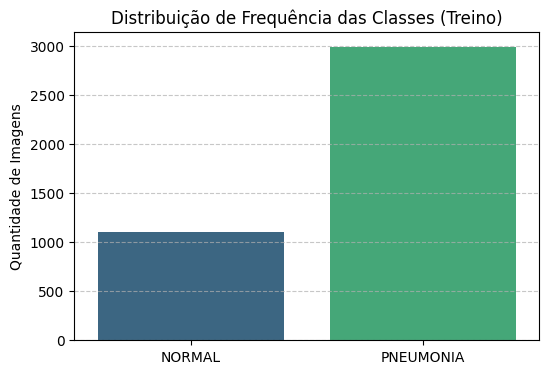

In [ ]:
def perform_eda(data_dir):
    train_dir = os.path.join(data_dir, 'train')
    classes = os.listdir(train_dir)
    frequencies = {}
    
    for cls in classes:
        frequencies[cls] = len(os.listdir(os.path.join(train_dir, cls)))
        
    total_samples = sum(frequencies.values())
    
    print("-" * 50)
    print("DISTRIBUIÇÃO DAS CLASSES NO CONJUNTO DE TREINO")
    print("-" * 50)
    for cls, count in frequencies.items():
        percentage = (count / total_samples) * 100
        print(f"Classe '{cls}': {count} imagens ({percentage:.2f}%)")
        
    # Gráfico de Frequência
    plt.figure(figsize=(6, 4))
    sns.barplot(x=list(frequencies.keys()), y=list(frequencies.values()), palette="viridis")
    plt.title("Distribuição de Frequência das Classes (Treino)")
    plt.ylabel("Quantidade de Imagens")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return frequencies

class_counts = perform_eda(CONFIG["data_dir"])

### Pré-processamento e tratamento de desbalanceamento

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instanciação dos Datasets usando ImageFolder
train_dataset = torchvision.datasets.ImageFolder(root=os.path.join(CONFIG["data_dir"], 'train'), transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=os.path.join(CONFIG["data_dir"], 'val'), transform=val_test_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=os.path.join(CONFIG["data_dir"], 'test'), transform=val_test_transforms)

# --- ABORDAGEM A: ESTRUTURAÇÃO DO WEIGHTEDRANDOMSAMPLER ---
class_weights_sampler = [1.0 / class_counts[train_dataset.classes[idx]] for idx in train_dataset.targets]
sampler_weights = torch.DoubleTensor(class_weights_sampler)
sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(sampler_weights), replacement=True)

# Dataloaders - Criaremos um dicionário para alternar facilmente entre as abordagens
dataloaders = {
    "sampler_train": DataLoader(train_dataset, batch_size=CONFIG["batch_size"], sampler=sampler),
    "standard_train": DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True),
    "val": DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False),
    "test": DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
}

#### calculo de class weights para loss

In [ ]:
# Inverso da frequência normalizada
total_train = sum(class_counts.values())
weights_list = [total_train / class_counts[cls] for cls in train_dataset.classes]
loss_class_weights = torch.FloatTensor(weights_list).to(device)

print(f"Pesos calculados para a Loss Function (Abordagem B): {loss_class_weights.cpu().numpy()}")

Pesos calculados para a Loss Function (Abordagem B): [3.6994586 1.3704447]


### cnn simples

In [ ]:
class MedicalCNNSimple(nn.Module):
    def __init__(self, num_classes=2):
        super(MedicalCNNSimple, self).__init__()
        
        # Bloco de Convolução 1
        self.features1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Bloco de Convolução 2 + Dropout para regularização (Requisito 4 e 6)
        self.features2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Bloco de Convolução 3
        self.features3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )
        
        # Camadas Densas / Classificador (Entrada calculada com base em 224x224 reduzido por 3 MaxPools de fator 2)
        # 224 -> 112 -> 56 -> 28
        self.classifier = nn.Sequential(
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features1(x)
        x = self.features2(x)
        x = self.features3(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

# Instanciação rápida para teste estrutural
model_cnn = MedicalCNNSimple(num_classes=2).to(device)
print(model_cnn)

MedicalCNNSimple(
  (features1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (features2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (features3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (classifier): Seq

### treinamento e avaliação da cnn simples


Iniciando treinamento da CNN Simples (Construída Manualmente)...
Época [1/15] | Treino Loss: 0.9709 Acc: 76.34% | Val Loss: 0.2289 Acc: 91.69%
Época [2/15] | Treino Loss: 0.3566 Acc: 85.46% | Val Loss: 0.2834 Acc: 87.13%
EarlyStopping contador: 1 de 3
Época [3/15] | Treino Loss: 0.3394 Acc: 85.85% | Val Loss: 0.2368 Acc: 88.50%
EarlyStopping contador: 2 de 3
Época [4/15] | Treino Loss: 0.3075 Acc: 87.00% | Val Loss: 0.1774 Acc: 93.17%
Época [5/15] | Treino Loss: 0.3011 Acc: 88.29% | Val Loss: 0.1877 Acc: 92.26%
EarlyStopping contador: 1 de 3
Época [6/15] | Treino Loss: 0.2586 Acc: 89.61% | Val Loss: 0.1725 Acc: 92.37%
Época [7/15] | Treino Loss: 0.2639 Acc: 89.34% | Val Loss: 0.1591 Acc: 93.17%
Época [8/15] | Treino Loss: 0.2695 Acc: 89.05% | Val Loss: 0.2565 Acc: 83.83%
EarlyStopping contador: 1 de 3
Época [9/15] | Treino Loss: 0.2609 Acc: 88.24% | Val Loss: 0.2082 Acc: 89.98%
EarlyStopping contador: 2 de 3
Época [10/15] | Treino Loss: 0.2809 Acc: 86.51% | Val Loss: 0.4194 Acc: 83.71

C:\Users\vitor\AppData\Local\Temp\ipykernel_9024\4075021303.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.79      0.96      0.87       238
   PNEUMONIA       0.98      0.91      0.94       641

    accuracy                           0.92       879
   macro avg       0.89      0.93      0.91       879
weighted avg       0.93      0.92      0.92       879



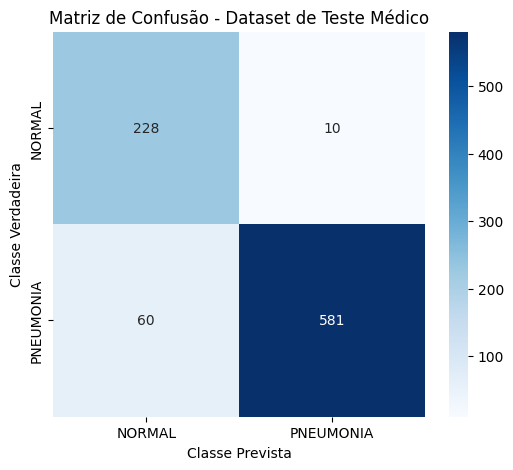


Curvas de Aprendizado - CNN Simples


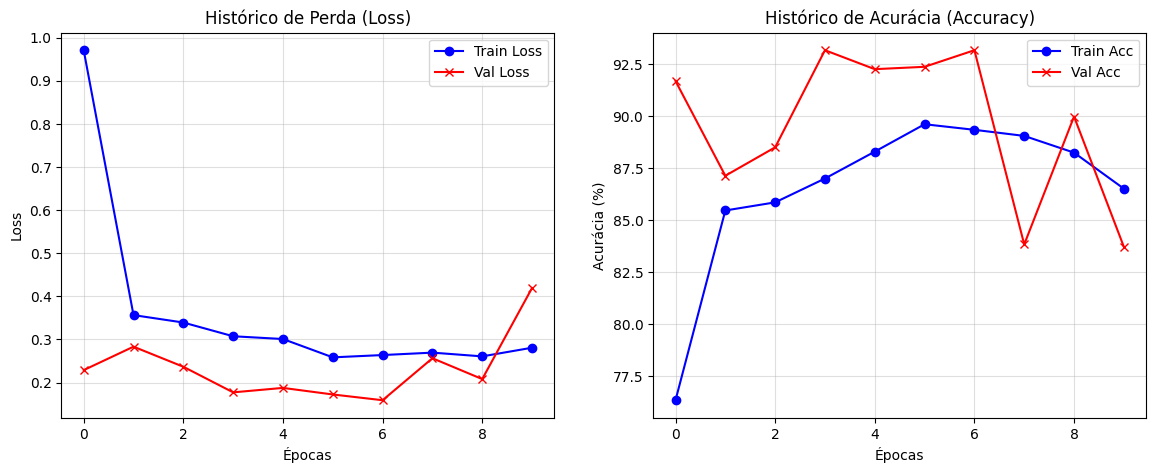


Inferências Reais - CNN Simples


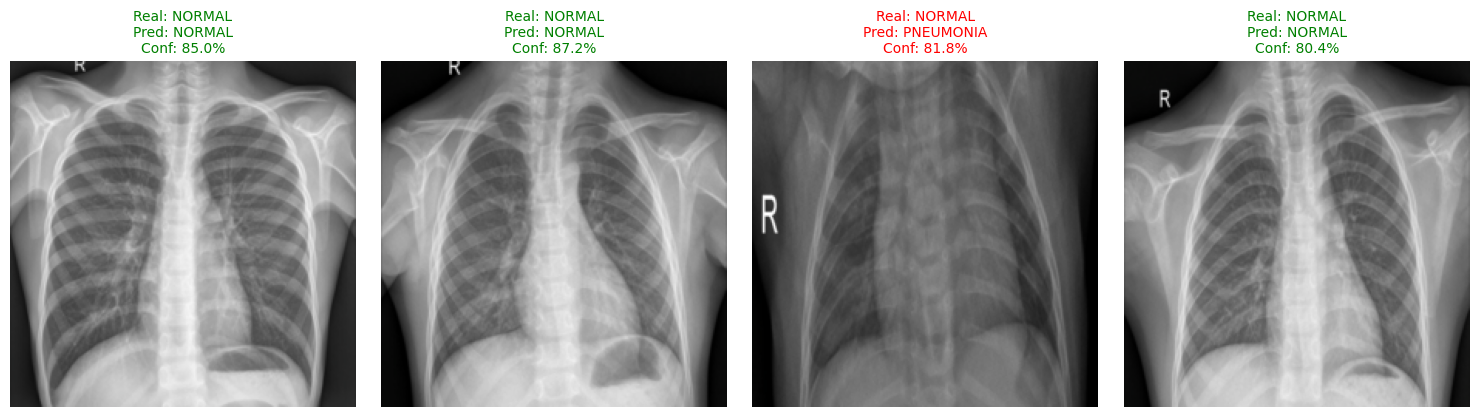

In [ ]:
print("\nIniciando treinamento da CNN Simples (Construída Manualmente)...")

# Configurando Otimizador e Scheduler específicos para a CNN simples
# Usando o DataLoader com Sampler para combater o desbalanceamento
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.1, patience=2)
criterion_cnn = nn.CrossEntropyLoss()

# Treinando a CNN Simples
model_cnn, cnn_history = train_model(
    model=model_cnn,
    criterion=criterion_cnn,
    optimizer=optimizer_cnn,
    scheduler=scheduler_cnn,
    train_loader=dataloaders["sampler_train"], # Abordagem A ativa
    val_loader=dataloaders["val"],
    epochs=CONFIG["epochs"],
    model_name="cnn_simple"
)

# 1. Avaliação completa da CNN Simples no conjunto de teste
print("\n" + "="*60)
print("AVALIAÇÃO DA CNN SIMPLES NO DATASET DE TESTE")
print("="*60)
evaluate_model(model_cnn, dataloaders["test"], train_dataset.classes)

# 2. Plotar curvas de aprendizado da CNN Simples
print("\nCurvas de Aprendizado - CNN Simples")
plot_curves(cnn_history)

# 3. Inferência visual com a CNN Simples
print("\nInferências Reais - CNN Simples")
visualize_predictions(model_cnn, dataloaders["test"], train_dataset.classes, num_images=4)

### Transfer learning (resnet50)

In [ ]:
def get_resnet50_transfer(num_classes=2, fine_tune=False):
    # Carrega pesos pré-treinados atualizados (Pytorch API atualizada)
    resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    if not fine_tune:
        # Passo 1: Congelar todo o backbone (Feature Extractor)
        for param in resnet.parameters():
            param.requires_grad = False
            
    # Substitui a última camada linear de classificação (In: 2048, Out: num_classes)
    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, num_classes)
    )
    return resnet.to(device)

model_resnet = get_resnet50_transfer(num_classes=2, fine_tune=False)

### loop de treinamento cp, early stopping

In [ ]:
class EarlyStopping:
    """Implementação limpa de Early Stopping para PyTorch."""
    def __init__(self, patience=3, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model, path="best_model.pth"):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model, path)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping contador: {self.counter} de {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model, path)
            self.counter = 0

    def save_checkpoint(self, model, path):
        torch.save(model.state_dict(), path)

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs, model_name="model"):
    early_stopping = EarlyStopping(patience=CONFIG["patience"])
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(1, epochs + 1):
        # Fase de Treino
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            # Envio explícito dos tensores e batches para GPU CUDA (Requisito 7)
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = (correct / total) * 100
        
        # Fase de Validação
        model.eval()
        running_val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad(): # Desliga o grafo de gradientes para poupar VRAM na GTX 1650
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100
        
        # Atualiza o Learning Rate Scheduler (Requisito 6)
        scheduler.step(epoch_val_loss)
        
        # Histórico para métricas
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Época [{epoch}/{epochs}] | Treino Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")
        
        # Execução do Early Stopping
        checkpoint_path = f"best_{model_name}.pth"
        early_stopping(epoch_val_loss, model, path=checkpoint_path)
        if early_stopping.early_stop:
            print("--> Gatilho do Early Stopping acionado. Interrompendo treinamento.")
            break
            
    # Garante o carregamento dos melhores pesos salvos antes do Overfitting disparar
    model.load_state_dict(torch.load(checkpoint_path))
    return model, history

### execução do treinamento (usando resnet50 + abordagem A: sampler como padrão)

In [ ]:
print("\nIniciando treinamento com ResNet50 (Fase 1: Classifier Only)...")
criterion_sampler = nn.CrossEntropyLoss() # Não precisa de pesos internos pois o loader já estabiliza os batches
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=2)

model_resnet, resnet_history = train_model(
    model=model_resnet,
    criterion=criterion_sampler,
    optimizer=optimizer_resnet,
    scheduler=scheduler_resnet,
    train_loader=dataloaders["sampler_train"], # Abordagem A ativa aqui
    val_loader=dataloaders["val"],
    epochs=CONFIG["epochs"],
    model_name="resnet_frozen"
)

# --- FASE DE FINE-TUNING POSTERIOR (Requisito 5) ---
print("\nIniciando Fase de Fine-Tuning Avançado da ResNet50...")
# Descongelar as últimas camadas (Layer 4 em diante)
for name, child in model_resnet.named_children():
    if name in ['layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True

# Otimizador com taxa de aprendizado extremamente baixa para não corromper os pesos funcionais
optimizer_ft = optim.Adam(model_resnet.parameters(), lr=1e-5, weight_decay=CONFIG["weight_decay"])
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=1)

model_resnet, resnet_ft_history = train_model(
    model=model_resnet,
    criterion=criterion_sampler,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    train_loader=dataloaders["sampler_train"],
    val_loader=dataloaders["val"],
    epochs=5, # Poucas épocas para ajuste fino cirúrgico
    model_name="resnet_finetuned"
)


Iniciando treinamento com ResNet50 (Fase 1: Classifier Only)...
Época [1/15] | Treino Loss: 0.3969 Acc: 83.36% | Val Loss: 0.4160 Acc: 80.75%
Época [2/15] | Treino Loss: 0.2892 Acc: 89.09% | Val Loss: 0.3189 Acc: 86.22%
Época [3/15] | Treino Loss: 0.2678 Acc: 89.51% | Val Loss: 0.2528 Acc: 90.55%
Época [4/15] | Treino Loss: 0.2620 Acc: 89.95% | Val Loss: 0.2713 Acc: 89.41%
EarlyStopping contador: 1 de 3
Época [5/15] | Treino Loss: 0.2382 Acc: 90.83% | Val Loss: 0.2465 Acc: 90.66%
Época [6/15] | Treino Loss: 0.2441 Acc: 90.56% | Val Loss: 0.2416 Acc: 90.89%
Época [7/15] | Treino Loss: 0.2426 Acc: 90.46% | Val Loss: 0.2885 Acc: 89.52%
EarlyStopping contador: 1 de 3
Época [8/15] | Treino Loss: 0.2358 Acc: 90.97% | Val Loss: 0.2135 Acc: 92.26%
Época [9/15] | Treino Loss: 0.2321 Acc: 91.14% | Val Loss: 0.2897 Acc: 88.95%
EarlyStopping contador: 1 de 3
Época [10/15] | Treino Loss: 0.2269 Acc: 90.95% | Val Loss: 0.2308 Acc: 91.23%
EarlyStopping contador: 2 de 3
Época [11/15] | Treino Loss: 0

C:\Users\vitor\AppData\Local\Temp\ipykernel_9024\4075021303.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


Época [1/5] | Treino Loss: 0.2110 Acc: 91.36% | Val Loss: 0.2621 Acc: 90.77%
Época [2/5] | Treino Loss: 0.2162 Acc: 91.95% | Val Loss: 0.2132 Acc: 92.03%
Época [3/5] | Treino Loss: 0.1846 Acc: 93.27% | Val Loss: 0.2270 Acc: 91.69%
EarlyStopping contador: 1 de 3
Época [4/5] | Treino Loss: 0.1801 Acc: 93.14% | Val Loss: 0.1960 Acc: 92.82%
Época [5/5] | Treino Loss: 0.1687 Acc: 93.54% | Val Loss: 0.1748 Acc: 93.51%


### Avaliação completa


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.88      0.96      0.92       238
   PNEUMONIA       0.99      0.95      0.97       641

    accuracy                           0.95       879
   macro avg       0.93      0.96      0.94       879
weighted avg       0.96      0.95      0.95       879



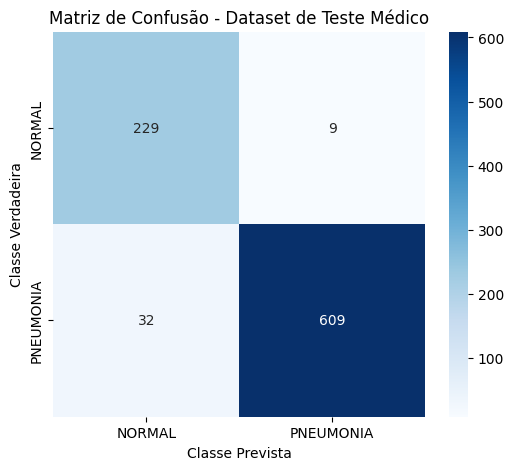

In [ ]:
def evaluate_model(model, test_loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Cálculos das métricas estruturadas
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusão - Dataset de Teste Médico')
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Prevista')
    plt.show()

evaluate_model(model_resnet, dataloaders["test"], train_dataset.classes)

### curvas de treinamento e diagnóstico

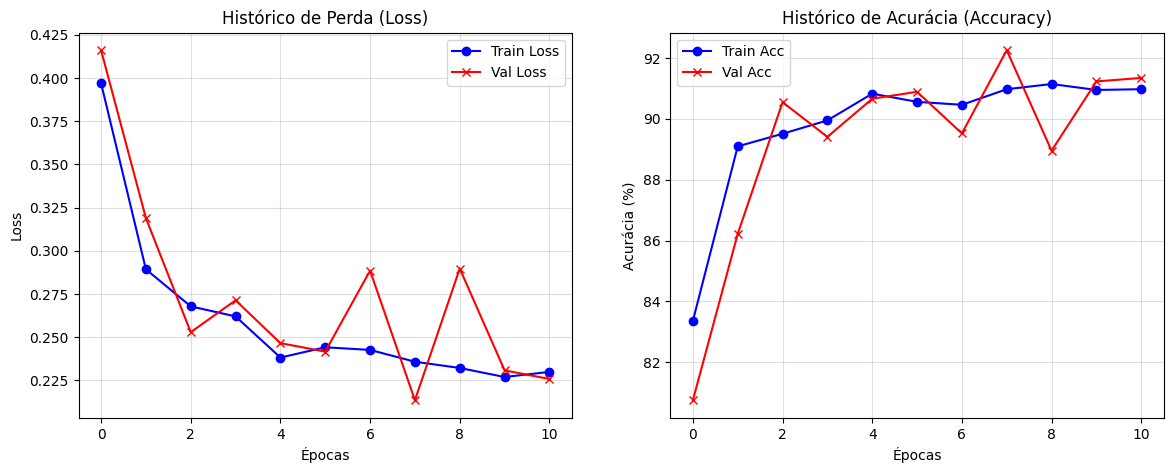

In [ ]:
def plot_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de Perda
    ax1.plot(history['train_loss'], label='Train Loss', color='b', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', color='r', marker='x')
    ax1.set_title('Histórico de Perda (Loss)')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.4)
    
    # Gráfico de Acurácia
    ax2.plot(history['train_acc'], label='Train Acc', color='b', marker='o')
    ax2.plot(history['val_acc'], label='Val Acc', color='r', marker='x')
    ax2.set_title('Histórico de Acurácia (Accuracy)')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Acurácia (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.4)
    
    plt.show()

# Exibindo as curvas consolidadas da primeira fase de treinamento da ResNet
plot_curves(resnet_history)

### inferencia com visualizações reais

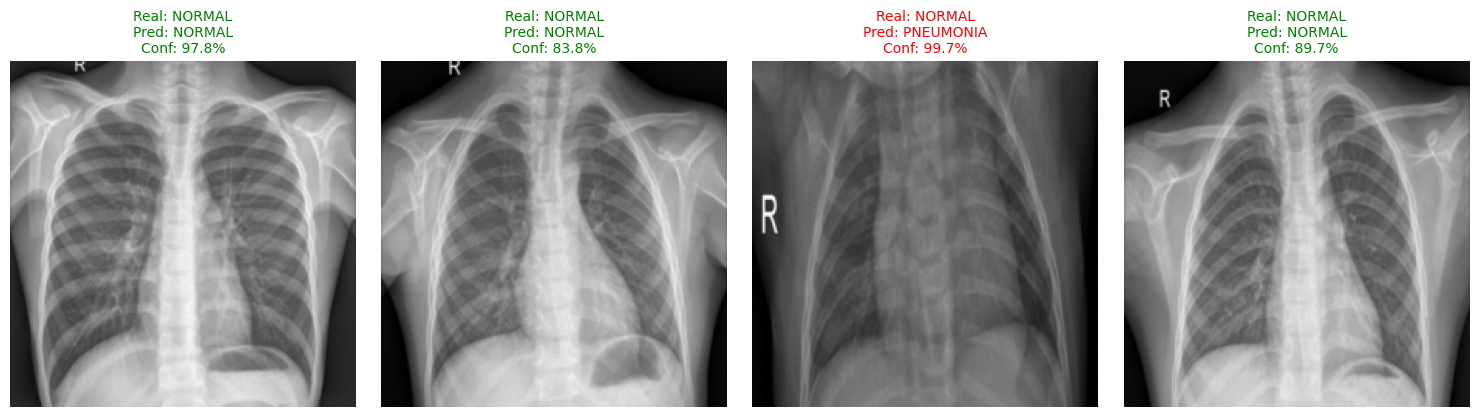

In [ ]:
def visualize_predictions(model, test_loader, classes, num_images=4):
    model.eval()
    images_shown = 0
    fig = plt.figure(figsize=(15, 4))
    
    # Desnormalização para plotagem correta do canal RGB mapeado
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predicted = probabilities.max(1)
            
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                    
                images_shown += 1
                ax = fig.add_subplot(1, num_images, images_shown)
                
                # Prepara imagem para exibição no matplotlib
                img_tensor = inv_normalize(inputs[i]).cpu().squeeze()
                img_array = img_tensor.permute(1, 2, 0).numpy()
                img_array = np.clip(img_array, 0, 1)
                
                true_cls = classes[labels[i].item()]
                pred_cls = classes[predicted[i].item()]
                conf = confidences[i].item() * 100
                
                color = 'green' if true_cls == pred_cls else 'red'
                
                ax.imshow(img_array)
                ax.axis('off')
                ax.set_title(f"Real: {true_cls}\nPred: {pred_cls}\nConf: {conf:.1f}%", color=color, fontsize=10)
                
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

visualize_predictions(model_resnet, dataloaders["test"], train_dataset.classes, num_images=4)